### *Import Library*

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import pyfeats
import joblib
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score


### *Preprocessing Data*

In [2]:
# =============================================
# Preprocessing Data (Grayscale, Resize, CLAHE)
# =============================================
input_dirs = {
    'Normal': 'C:/SKRIPSI/Dataset/NORMAL',
    'Tuberculosis': 'C:/SKRIPSI/Dataset/TUBERCULOSIS',
    'Pneumonia': 'C:/SKRIPSI/Dataset/PNEUMONIA',
    'Covid19': 'C:/SKRIPSI/Dataset/COVID19'
}
label_map = {'Normal': 0, 'Tuberculosis': 1, 'Pneumonia': 2, 'Covid19': 3}

processed_images = []
labels = []

for label, folder in input_dirs.items():
    for fname in tqdm(os.listdir(folder), desc=f"Preprocessing {label}"):
        if fname.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img)
            processed_images.append(img)
            labels.append(label_map[label])

Preprocessing Normal:   0%|          | 0/1000 [00:00<?, ?it/s]

Preprocessing Covid19: 100%|██████████| 1000/1000 [00:31<00:00, 31.59it/s]


### *Estraksi Fitur*

In [3]:
# ===============================
# Ekstraksi Fitur FOS
# ===============================
fos_list = []
for img in tqdm(processed_images, desc="Ekstraksi FOS"):
    mask = np.ones_like(img)
    fos, _ = pyfeats.fos(img, mask)
    fos_list.append(fos[:10])

fos_df = pd.DataFrame(fos_list, columns=[
    'FOS_Mean', 'FOS_StdDev', 'FOS_Median', 'FOS_Mode', 'FOS_Skewness',
    'FOS_Kurtosis', 'FOS_Energy', 'FOS_Entropy', 'FOS_Min', 'FOS_Max'])
fos_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi FOS selesai")
# print(fos_df.head())

# fos_df.to_csv("fitur_fos.csv", index=False)

Ekstraksi FOS:   0%|          | 0/4000 [00:00<?, ?it/s]

Ekstraksi FOS: 100%|██████████| 4000/4000 [01:23<00:00, 48.18it/s]


In [4]:
# ===============================
# Ekstraksi Fitur GLCM
# ===============================
glcm_list = []
for img in tqdm(processed_images, desc="Ekstraksi GLCM"):
    glcm = pyfeats.glcm_features(img)
    combined = np.concatenate([glcm[0], glcm[1]])
    drop = [i for i in [12, 13, 14, 20, 26, 27, 28] if i < len(combined)]
    glcm_filtered = np.delete(combined, drop)
    glcm_list.append(glcm_filtered)

glcm_df = pd.DataFrame(glcm_list, columns=[
    'GLCM_ASM_Mean', 'GLCM_Contrast_Mean', 'GLCM_Correlation_Mean', 'GLCM_SumOfSquaresVariance_Mean',
    'GLCM_InverseDifferenceMoment_Mean', 'GLCM_SumAverage_Mean', 'GLCM_SumVariance_Mean', 'GLCM_SumEntropy_Mean',
    'GLCM_Entropy_Mean', 'GLCM_DifferenceVariance_Mean', 'GLCM_DifferenceEntropy_Mean',
    'GLCM_ASM_Range', 'GLCM_Contrast_Range', 'GLCM_Correlation_Range', 'GLCM_SumOfSquaresVariance_Range',
    'GLCM_InverseDifferenceMoment_Range', 'GLCM_SumAverage_Range', 'GLCM_SumVariance_Range', 'GLCM_SumEntropy_Range',
    'GLCM_Entropy_Range', 'GLCM_DifferenceVariance_Range', 'GLCM_DifferenceEntropy_Range'])
glcm_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi GLCM selesai")
# # print(glcm_df.head())

# glcm_df.to_csv("fitur_glcm.csv", index=False)

Ekstraksi GLCM: 100%|██████████| 4000/4000 [05:41<00:00, 11.72it/s]


In [5]:
# ===============================
# Gabungkan Fitur
# ===============================
fos_only = fos_df.drop(columns=['Label'])
glcm_only = glcm_df.drop(columns=['Label'])
combined_df = pd.concat([pd.Series(labels, name='Label'), fos_only, glcm_only], axis=1)

print("\n✅ Fitur gabungan FOS + GLCM")
# print(combined_df.head())

# combined_df.to_csv("fitur_gabungan.csv", index=False)


✅ Fitur gabungan FOS + GLCM


### *Feature removal*

In [7]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from scipy.stats import zscore
import joblib

# ===== Custom Transformer =====
class ZScoreMasking(BaseEstimator, TransformerMixin):
    def __init__(self, mask=None):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.mask is None:
            return X
        return X[:, self.mask]

# ===== Load Dataset =====
X = combined_df.drop(columns=['Label']).values
y = combined_df['Label'].values
feature_names = combined_df.drop(columns=['Label']).columns

print("\n📊 Jumlah fitur awal:", X.shape[1])

# ===== Hitung Statistik =====
z = np.abs(zscore(X))
mean_z = z.mean(axis=0)
var = X.var(axis=0)

print("\n🔍 Statistik per fitur:")
for i, name in enumerate(feature_names):
    print(f"  {name:20} | mean_z: {mean_z[i]:.4f} | var: {var[i]:.6f}")

# ===== Grid Threshold Setup =====
thresh_range = np.arange(0.5, 4.5, 0.25)
param_grid = []
mask_dict = {}

for t in thresh_range:
    mask = (mean_z < t) & (var > 1e-5)
    selected = np.where(mask)[0]

    if len(selected) > 1:
        corr = np.corrcoef(X[:, selected].T)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                if abs(corr[i, j]) > 0.95:
                    if mean_z[selected[i]] > mean_z[selected[j]]:
                        mask[selected[i]] = False
                    else:
                        mask[selected[j]] = False

    mask_dict[t] = mask
    print(f"📌 Threshold: {t:.2f} | Fitur tersisa: {mask.sum()}")

    param_grid.append({
        'mask__mask': [mask],
        'svc__C': [0.1, 1.0, 10.0]
    })

# ===== Build Pipeline =====
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mask', ZScoreMasking()),
    ('svc', LinearSVC(max_iter=100000, dual=False))
])

# ===== GridSearch =====
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

# ===== Ambil Kombinasi dengan Fitur < Penuh =====
results = grid.cv_results_
filtered = [
    (i, params['mask__mask'])
    for i, params in enumerate(results['params'])
    if params['mask__mask'].sum() < X.shape[1]
]

if filtered:
    # Ambil skor tertinggi di antara konfigurasi yang mengurangi fitur
    best_i, best_mask = max(
        filtered,
        key=lambda x: results['mean_test_score'][x[0]]
    )
    best_threshold = [
        t for t, m in mask_dict.items() if np.array_equal(m, best_mask)
    ][0]
    best_pipeline = grid.cv_results_['params'][best_i]
    final_model = grid.best_estimator_
else:
    # Tidak ada fitur yang terfilter → fallback
    best_mask = grid.best_params_['mask__mask']
    best_threshold = [t for t, m in mask_dict.items() if np.array_equal(m, best_mask)][0]
    final_model = grid.best_estimator_

X_filtered = X[:, best_mask]

# ===== Output Hasil =====
print("\n✅ Threshold terbaik:", best_threshold)
print("📊 Jumlah fitur sebelum masking:", X.shape[1])
print("✅ Jumlah fitur setelah masking:", X_filtered.shape[1])
print("✅ Fitur yang dipertahankan:", feature_names[best_mask].tolist())



📊 Jumlah fitur awal: 32

🔍 Statistik per fitur:
  FOS_Mean             | mean_z: 0.7686 | var: 295.119847
  FOS_StdDev           | mean_z: 0.7917 | var: 1586195.202343
  FOS_Median           | mean_z: 0.7348 | var: 481.812344
  FOS_Mode             | mean_z: 0.9565 | var: 9896.149880
  FOS_Skewness         | mean_z: 0.7269 | var: 0.098030
  FOS_Kurtosis         | mean_z: 0.6360 | var: 0.379073
  FOS_Energy           | mean_z: 0.2567 | var: 0.001090
  FOS_Entropy          | mean_z: 0.5306 | var: 0.069346
  FOS_Min              | mean_z: 0.4520 | var: 17.464147
  FOS_Max              | mean_z: 0.4926 | var: 42.048296
  GLCM_ASM_Mean        | mean_z: 0.2569 | var: 0.001068
  GLCM_Contrast_Mean   | mean_z: 0.7797 | var: 22770.867365
  GLCM_Correlation_Mean | mean_z: 0.6717 | var: 0.000598
  GLCM_SumOfSquaresVariance_Mean | mean_z: 0.7907 | var: 1570216.266802
  GLCM_InverseDifferenceMoment_Mean | mean_z: 0.7113 | var: 0.006161
  GLCM_SumAverage_Mean | mean_z: 0.7684 | var: 1166.508828
  G

### *Split Data dan Normalisasi*

In [8]:
# ===============================
# ⚙️ 6. Split & Normalisasi
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### *Modeling SVM*

Fitting 5 folds for each of 55 candidates, totalling 275 fits

✅ Parameter Terbaik: {'C': 10.0, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
✅ Akurasi CV Terbaik: 0.9041
✅ Akurasi pada data uji: 0.9137

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92       200
Tuberculosis       0.96      0.96      0.96       200
   Pneumonia       0.88      0.89      0.89       200
     Covid19       0.93      0.85      0.89       200

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



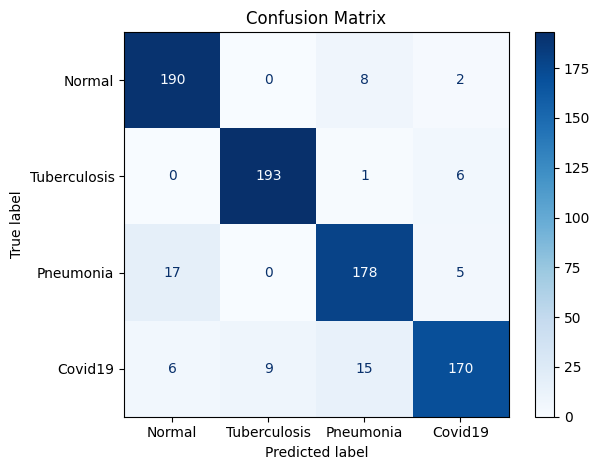

In [10]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# ------------------------
# Parameter Grid SVM
# ------------------------
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'class_weight': ['balanced']
    }
]

# ------------------------
# Grid Search CV
# ------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

# ------------------------
# Tampilkan hasil terbaik
# ------------------------
print("\n✅ Parameter Terbaik:", grid.best_params_)
print(f"✅ Akurasi CV Terbaik: {grid.best_score_:.4f}")

# ------------------------
# Evaluasi di Test Data
# ------------------------
model = grid.best_estimator_
test_acc = model.score(X_test_scaled, y_test)
print(f"✅ Akurasi pada data uji: {test_acc:.4f}")

y_pred = model.predict(X_test_scaled)

# Tambahkan label_names
label_names = list(label_map.keys())  # Fix error di sini

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# ============================
# 📉 Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


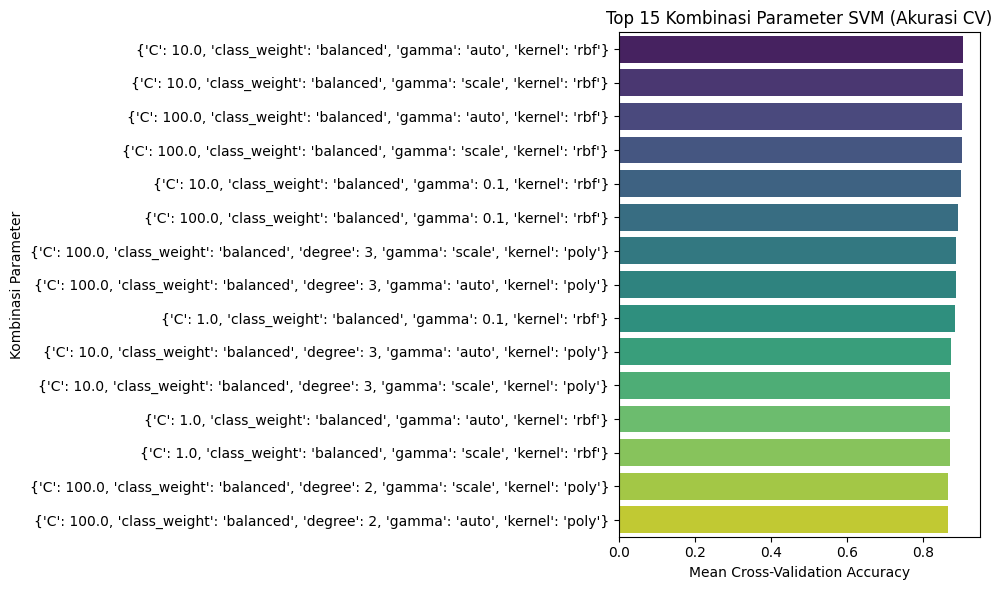

In [12]:
import seaborn as sns

# Ambil hasil grid search dalam DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# Gabungkan parameter menjadi string
cv_results["params_str"] = cv_results["params"].astype(str)

# Urutkan berdasarkan skor tertinggi
top_cv = cv_results.sort_values(by="mean_test_score", ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cv, x="mean_test_score", y="params_str", hue="params_str", dodge=False, palette="viridis", legend=False)
plt.title("Top 15 Kombinasi Parameter SVM (Akurasi CV)")
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Kombinasi Parameter")
plt.tight_layout()
plt.show()


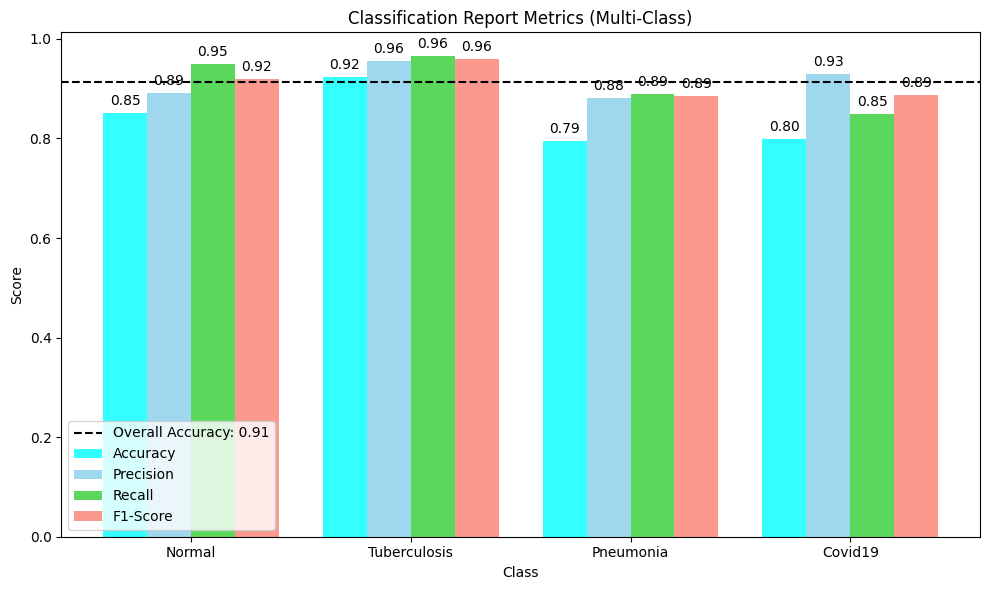


📊 Akurasi per kelas:
- Normal: 0.85
- Tuberculosis: 0.92
- Pneumonia: 0.79
- Covid19: 0.80

📊 Precision : [0.89 0.96 0.88 0.93]
📊 Recall    : [0.95 0.96 0.89 0.85]
📊 F1-Score  : [0.92 0.96 0.89 0.89]
🎯 Overall Accuracy: 0.91


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Prediksi
y_pred = model.predict(X_test_scaled)
unique_classes = np.unique(y_test)
num_classes = len(unique_classes)

# Nama kelas sesuai urutan label (ganti sesuai model kamu)
classes = ['Normal', 'Tuberculosis', 'Pneumonia', 'Covid19']

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

# Akurasi per kelas
accuracy_per_class = []
for i in range(num_classes):
    tp = cm[i, i]
    fp = sum(cm[:, i]) - tp
    fn = sum(cm[i, :]) - tp
    acc_class = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    accuracy_per_class.append(acc_class)

# Precision, Recall, F1-score
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=unique_classes
)

overall_accuracy = model.score(X_test_scaled, y_test)

# ========== PLOT ==========
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
index = np.arange(num_classes)

bars1 = ax.bar(index, accuracy_per_class, bar_width, label='Accuracy', color='cyan', alpha=0.8)
bars2 = ax.bar(index + bar_width, precision, bar_width, label='Precision', color='skyblue', alpha=0.8)
bars3 = ax.bar(index + 2 * bar_width, recall, bar_width, label='Recall', color='limegreen', alpha=0.8)
bars4 = ax.bar(index + 3 * bar_width, f1, bar_width, label='F1-Score', color='salmon', alpha=0.8)

# Garis Overall Accuracy
ax.axhline(y=overall_accuracy, color='black', linestyle='--', label=f'Overall Accuracy: {overall_accuracy:.2f}')

# Label dan Judul
ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Classification Report Metrics (Multi-Class)')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels([classes[i] for i in unique_classes])
ax.legend()

# Tambahkan nilai di atas batang
for bar_set in [bars1, bars2, bars3, bars4]:
    for bar in bar_set:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print metrics ke terminal
print("\n📊 Akurasi per kelas:")
for i, class_name in enumerate([classes[i] for i in unique_classes]):
    print(f"- {class_name}: {accuracy_per_class[i]:.2f}")

print(f"\n📊 Precision : {np.round(precision, 2)}")
print(f"📊 Recall    : {np.round(recall, 2)}")
print(f"📊 F1-Score  : {np.round(f1, 2)}")
print(f"🎯 Overall Accuracy: {overall_accuracy:.2f}")


### *AUC*

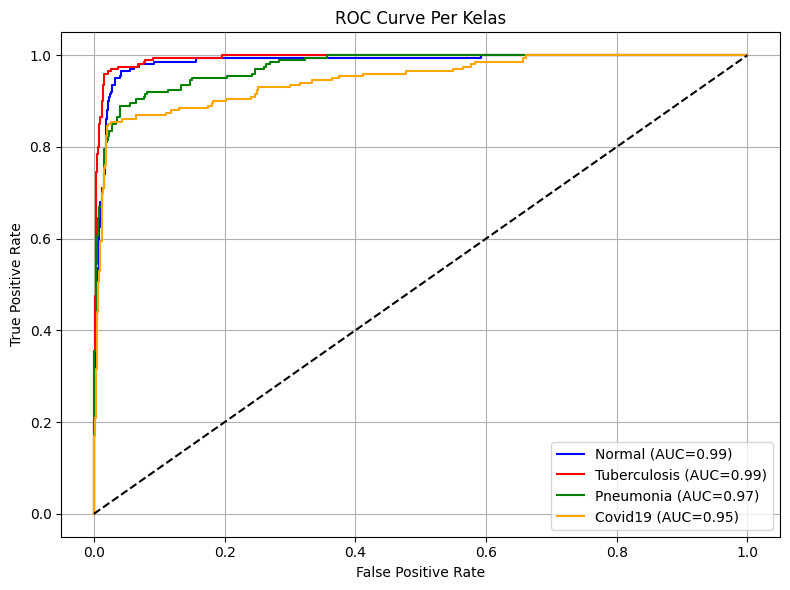

In [14]:
# ROC Curve
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
scores = model.decision_function(X_test_scaled)
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i, label in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{label} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Per Kelas")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### *Save Model*

In [16]:
# # Simpan model dan tools
joblib.dump(model, 'model_svm.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(best_mask, 'best_mask_kombinasi.pkl')
print("\nModel dan file preprocessing berhasil disimpan!")


Model dan file preprocessing berhasil disimpan!
